# 🧪 Validación Externa — 4 Estrategias de Pooling

Este notebook evalúa, sobre el **mismo conjunto de prueba**, a la mejor arquitectura de cada una de las 4 estrategias de agregación de embeddings exploradas en el proyecto:

| Estrategia | Arquitectura | AAontology | Input al modelo |
|---|---|---|---|
| **Mean Pooling** | `BiLSTMClassifier` | ❌ | vector plano `(B, 768)` |
| **Mean Pooling + AAontology** | `MLPClassifier` | ✅ | vector plano `(B, 776)` = embedding + perfil AAontology mean-pooled |
| **Gated Pooling** | `GatedConv1DClassifier` | ❌ | por residuo `X(B,L,768)`, `M(B,L)` |
| **Gated Pooling + AAontology** | `GatedMLPClassifier` | ✅ | por residuo `X(B,L,768)`, `G(B,L,8)`, `M(B,L)` |

Como los 4 modelos requieren *inputs* distintos, este notebook usa **dos pipelines de datos en paralelo** sobre el mismo test set:
- `test_dataset.csv` (embeddings ya mean-pooled) → para los dos modelos de **Mean Pooling**.
- `test_dataset.pt` (tensores por residuo, formato `AMPDataset`) → para los dos modelos de **Gated Pooling**.


## 📦 Importación de Librerías

In [1]:
import os
import json
import ast
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    matthews_corrcoef, confusion_matrix, balanced_accuracy_score,
    roc_curve, precision_recall_curve,
)

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings("ignore")

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())

torch: 2.10.0+cu128
cuda: True


## ⚙️ Configuración

In [2]:
# ========== PATHS ==========
EVAL_DIR    = Path("/kaggle/working/Validation/PoolingComparison")
EVAL_DIR.mkdir(parents=True, exist_ok=True)

TEST_CSV = "/kaggle/input/datasets/user/test-dataset-csv/test_dataset.csv"   # formato plano: embedding, sequence, label
TEST_PT  = "/kaggle/input/datasets/user/dataset-created/test_dataset.pt"    # formato AMPDataset: X, G, M, seq, y por residuo

AAONTOLOGY_PATH = Path("/kaggle/input/datasets/user/aantology/aa_ontology_zscored.pt")

# ---- Checkpoints: uno por estrategia de pooling ----
BILSTM_MEAN_CKPT            = "/kaggle/input/datasets/user/meanpoolingmdels/lstm_best_model_final.pth"               # Mean Pooling
MLP_MEAN_AAONTOLOGY_CKPT    = "/kaggle/input/datasets/user/meanpoolingmdels/mlp_best_model_final.pth"                # Mean Pooling + AAontology
CONV_GATED_CKPT             = "/kaggle/input/datasets/user/cnn-results/CNN_Results/best_model_final.pth"             # Gated Pooling
MLP_GATED_AAONTOLOGY_CKPT   = "/kaggle/input/datasets/user/mlp-aantology-results/MLP_Results/best_model_final.pth"   # Gated Pooling + AAontology

PROT_EMBED_DIM = 768   # Dimensión del embedding ProtFlash

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
THRESHOLD  = 0.5

print(f"DEVICE: {DEVICE}")

DEVICE: cuda


## 🧬 Carga del Tensor Fisicoquímico (AAontology)

In [3]:
if AAONTOLOGY_PATH.exists():
    aa_data = torch.load(AAONTOLOGY_PATH, map_location="cpu", weights_only=True)
    AAONTOLOGY_ZSCORED = aa_data["tensor"]        # (n_aa, n_cat)
    AA_ORDER            = aa_data["amino_acids"]   # lista de aminoácidos (incluye 'X')
    USED_CATEGORIES     = aa_data["categories"]    # nombres de las categorías AAontology
else:
    raise FileNotFoundError(
        f"No se encontró {AAONTOLOGY_PATH}. Genera el tensor primero con el notebook "
        "3-AAontology_zscored_tensor_generator."
    )

AA_TO_IDX = {aa: i for i, aa in enumerate(AA_ORDER)}
N_CAT = AAONTOLOGY_ZSCORED.shape[1]

print(f"AAontology tensor: {tuple(AAONTOLOGY_ZSCORED.shape)}")
print(f"Categorías ({N_CAT}): {USED_CATEGORIES}")

AAontology tensor: (21, 8)
Categorías (8): ['ASA/Volume', 'Composition', 'Conformation', 'Energy', 'Polarity', 'Shape', 'Structure-Activity', 'Others']


## 🏗️ Definición de las 4 Arquitecturas

### Mean Pooling — `BiLSTMClassifier`

In [4]:
class BiLSTMClassifier(nn.Module):
    """Bidirectional LSTM classifier."""
    def __init__(self, input_dim: int, hidden_dim: int = 256,
                 num_layers: int = 2, dropout: float = 0.3,
                 bidirectional: bool = True):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0
        )

        lstm_output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.classifier = nn.Sequential(
            nn.LayerNorm(lstm_output_dim),
            nn.Dropout(dropout),
            nn.Linear(lstm_output_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, input_dim) -> (batch, 1, input_dim)
        x = x.unsqueeze(1)
        lstm_out, (hidden, cell) = self.lstm(x)
        if self.bidirectional:
            hidden_forward = hidden[-2]
            hidden_backward = hidden[-1]
            features = torch.cat([hidden_forward, hidden_backward], dim=1)
        else:
            features = hidden[-1]
        return self.classifier(features)


def build_model_lstm(config: Dict, input_dim: int) -> nn.Module:
    return BiLSTMClassifier(
            input_dim=input_dim,
            hidden_dim=config['hidden_dim'],
            num_layers=config['num_layers'],
            dropout=config['dropout'],
            bidirectional=config.get('bidirectional', True)
        )

### Mean Pooling + AAontology — `MLPClassifier`

In [5]:
class MLPClassifier(nn.Module):
    """Flexible MLP for binary classification."""
    def __init__(
        self,
        input_dim: int,
        hidden_dims: List[int],
        dropout: float = 0.3,
        use_batch_norm: bool = True,
        activation: str = "gelu",
    ):
        super().__init__()
        act_fn = nn.GELU() if activation == "gelu" else nn.ReLU()
        layers: List[nn.Module] = []
        if use_batch_norm:
            layers.append(nn.LayerNorm(input_dim))
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batch_norm:
                layers.append(nn.LayerNorm(h))
            layers.append(act_fn)
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def build_model_mlp(config: Dict, input_dim: int) -> nn.Module:
    return MLPClassifier(
        input_dim=input_dim,
        hidden_dims=config["hidden_dims"],
        dropout=config["dropout"],
        use_batch_norm=config.get("batch_norm", True),
        activation=config.get("activation", "gelu"),
    )

### Gated Pooling — `GatedPooler` + `GatedConv1DClassifier`

In [6]:
class GatedPooler(nn.Module):
    """
    Gated pooling diferenciable (sin AAontology).

    Input:
        - X: (B, L, D) embeddings por residuo
        - M: (B, L) máscara binaria

    Output:
        - E: (B, D) embedding agregado por secuencia
    """
    def __init__(self, input_dim: int):
        super().__init__()
        self.gating_mlp = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
        self.proj = nn.Linear(input_dim, input_dim)

    def forward(self, X: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        gates = self.gating_mlp(X) * M.unsqueeze(-1)   # (B, L, 1)
        weighted = gates * self.proj(X)
        return weighted.sum(dim=1) / (gates.sum(dim=1) + 1e-8)

    def get_gates(self, X: torch.Tensor, M: torch.Tensor):
        gates = self.gating_mlp(X)
        gates = gates * M.unsqueeze(-1)
        return gates


class GatedConv1DClassifier(nn.Module):
    """1D-CNN classifier con Gated Pooling."""
    def __init__(
        self,
        input_dim: int,
        conv_channels: List[int],
        kernel_sizes: List[int],
        mlp_hidden: List[int],
        dropout: float = 0.3,
    ):
        super().__init__()

        self.pooler = GatedPooler(input_dim=input_dim)

        self.convs = nn.ModuleList()
        in_channels = input_dim
        for out_channels, k_size in zip(conv_channels, kernel_sizes):
            self.convs.append(
                nn.Sequential(
                    nn.Conv1d(in_channels, out_channels, kernel_size=k_size, padding="same"),
                    nn.BatchNorm1d(out_channels),
                    nn.GELU(),
                    nn.Dropout1d(dropout),
                )
            )
            in_channels = out_channels

        cnn_out_dim = in_channels * 2  # MaxPool + AvgPool
        clf_in_dim = cnn_out_dim + input_dim + input_dim  # CNN + Global + Gated

        layers = []
        for h_dim in mlp_hidden:
            layers.append(nn.Linear(clf_in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            clf_in_dim = h_dim

        self.mlp = nn.Sequential(*layers)
        self.classifier = nn.Linear(clf_in_dim, 1)

    def forward(self, X: torch.Tensor, G: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        E = self.pooler(X, M)

        x_cnn = X.transpose(1, 2)  # (B,L,D) -> (B,D,L)
        for conv in self.convs:
            x_cnn = conv(x_cnn)
            x_cnn = x_cnn * M.unsqueeze(1)

        mask_bool = M.unsqueeze(1).bool()
        x_cnn_max = x_cnn.masked_fill(~mask_bool, -1e9)
        max_pooled = F.adaptive_max_pool1d(x_cnn_max, 1).squeeze(-1)

        sum_pooled = x_cnn.sum(dim=-1)
        lengths = M.sum(dim=-1, keepdim=True).clamp(min=1e-8)
        avg_pooled = sum_pooled / lengths

        cnn_features = torch.cat([max_pooled, avg_pooled], dim=1)
        combined = torch.cat([cnn_features, G, E], dim=1)
        x = self.mlp(combined)
        return self.classifier(x)

    def get_gates(self, X: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        return self.pooler.get_gates(X, M).squeeze(-1)


def build_cnn_model(config: Dict, input_dim: int) -> nn.Module:
    return GatedConv1DClassifier(
        input_dim,
        config["conv_channels"],
        config["kernel_sizes"],
        config["mlp_hidden"],
        config["dropout"],
    )

### Gated Pooling + AAontology — `AAontologyGatedPooler` + `GatedMLPClassifier`

In [7]:
class AAontologyGatedPooler(nn.Module):
    """
    Gated Pooling que combina el contexto de ProtFlash (X)
    con el prior bioquímico de AAontology (G).
    """
    def __init__(self, input_dim: int = 768, n_categories: int = 8):
        super().__init__()
        self.n_categories = n_categories

        self.ont_proj = nn.Linear(n_categories, 64)

        self.gating_mlp = nn.Sequential(
            nn.Linear(input_dim + 64, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

        self.proj = nn.Linear(input_dim, input_dim)

    def forward(self, X: torch.Tensor, G: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        """
        X: (B, L, 768) - ProtFlash
        G: (B, L, 8)   - AAontology precalculada (viene del Dataset)
        M: (B, L)      - Mask
        """
        ont_proj = self.ont_proj(G)
        combined_features = torch.cat([X, ont_proj], dim=-1)
        gates = self.gating_mlp(combined_features) * M.unsqueeze(-1)
        weighted = gates * self.proj(X) * M.unsqueeze(-1)
        return weighted.sum(dim=1) / (M.sum(dim=1, keepdim=True) + 1e-8)


class GatedMLPClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: List[int], dropout: float = 0.3, n_categories: int = 8):
        super().__init__()

        self.pooler = AAontologyGatedPooler(input_dim=input_dim, n_categories=n_categories)

        layers = []
        in_features = input_dim * 2  # Local Gated + Global Context

        for out_features in hidden_dims:
            layers.append(nn.Linear(in_features, out_features))
            layers.append(nn.BatchNorm1d(out_features))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            in_features = out_features

        self.mlp_body = nn.Sequential(*layers)
        self.classifier = nn.Linear(in_features, 1)

    def forward(self, X: torch.Tensor, ont_profiles: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        """
        X: (B, L, 768) - ProtFlash embeddings
        ont_profiles: (B, L, 8) - AAontology per-residue features
        M: (B, L) - Binary mask
        """
        E_local = self.pooler(X, ont_profiles, M)

        mask_expanded = M.unsqueeze(-1)
        E_global = (X * mask_expanded).sum(dim=1) / (M.sum(dim=1, keepdim=True) + 1e-8)

        combined_features = torch.cat([E_local, E_global], dim=1)
        x = self.mlp_body(combined_features)
        return self.classifier(x)

    def get_gates(self, X: torch.Tensor, ont_profiles: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        """Extrae los valores de gate para explicabilidad (XAI / SHAP / IG)."""
        ont_proj = self.pooler.ont_proj(ont_profiles)
        combined_features = torch.cat([X, ont_proj], dim=-1)
        gates = self.pooler.gating_mlp(combined_features)
        return gates.squeeze(-1) * M


def build_gated_model(config: Dict, input_dim: int) -> nn.Module:
    return GatedMLPClassifier(input_dim, config["hidden_dims"], config["dropout"])

## 📄 Carga de Datos — Pipeline Plano (Mean Pooling / Mean Pooling + AAontology)

In [8]:
def parse_embedding(value) -> np.ndarray:
    if isinstance(value, np.ndarray):
        return value.astype(np.float32)
    if isinstance(value, list):
        return np.array(value, dtype=np.float32)
    if isinstance(value, str):
        try:
            return np.array(json.loads(value), dtype=np.float32)
        except (json.JSONDecodeError, ValueError):
            return np.array(ast.literal_eval(value), dtype=np.float32)
    raise TypeError(f"Cannot parse embedding of type {type(value)}")


def compute_aaontology_mean_features(
    sequences: List[str],
    aa_profiles: torch.Tensor,
    aa_to_idx: Dict[str, int],
) -> np.ndarray:
    """
    Promedio (MEAN POOLING) de los perfiles AAontology (z-scored) por secuencia.
    Mismo criterio de agregación que ya se usa para los embeddings de ProtFlash.
    """
    n_cat = aa_profiles.shape[1]
    profiles_np = aa_profiles.numpy()
    feats = np.zeros((len(sequences), n_cat), dtype=np.float32)

    for i, seq in enumerate(sequences):
        idxs = [aa_to_idx[a] for a in seq if a in aa_to_idx]
        if idxs:
            feats[i] = profiles_np[idxs].mean(axis=0)
        # Secuencia sin AA reconocidos -> vector neutro en cero

    return feats.astype(np.float32)


def load_flat_test_data(
    csv_path: Path,
    aa_profiles: torch.Tensor,
    aa_to_idx: Dict[str, int],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Carga el CSV plano UNA sola vez y devuelve DOS variantes de features:
      - X_768: solo embedding ProtFlash mean-pooled -> para BiLSTM (Mean Pooling)
      - X_776: embedding + AAontology mean-pooled   -> para MLP (Mean Pooling + AAontology)
    """

    df = pd.read_csv(csv_path)
    required = {"embedding", "label", "sequence"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}. Found: {list(df.columns)}")

    print(f"Loading: {len(df)} samples ... ", end="", flush=True)

    embeddings_list = [parse_embedding(row) for row in df["embedding"]]
    X_768 = np.stack(embeddings_list, axis=0).astype(np.float32)

    X_aaonto = compute_aaontology_mean_features(
        df["sequence"].astype(str).tolist(), aa_profiles, aa_to_idx
    )
    X_776 = np.concatenate([X_768, X_aaonto], axis=1).astype(np.float32)

    y = df["label"].to_numpy().astype(np.int64)

    print(f"X_768={X_768.shape}, X_776={X_776.shape}, y={y.shape}")
    return X_768, X_776, y

### Cargar Datos de Prueba (formato plano)

In [9]:
X_test_768, X_test_776, y_test_flat = load_flat_test_data(TEST_CSV, AAONTOLOGY_ZSCORED, AA_TO_IDX)

pos = int(y_test_flat.sum())
neg = len(y_test_flat) - pos
print(f"Test set: total={len(y_test_flat)}, pos={pos}, neg={neg}, pos_ratio={pos/len(y_test_flat):.3f}")

# ---- Loader para BiLSTM (Mean Pooling, 768) ----
X_768_tensor = torch.from_numpy(X_test_768).float()
y_flat_tensor = torch.from_numpy(y_test_flat).float().view(-1, 1)
test_loader_mean = DataLoader(
    torch.utils.data.TensorDataset(X_768_tensor, y_flat_tensor),
    batch_size=BATCH_SIZE, shuffle=False,
)

# ---- Loader para MLP (Mean Pooling + AAontology, 776) ----
X_776_tensor = torch.from_numpy(X_test_776).float()
test_loader_mean_aaonto = DataLoader(
    torch.utils.data.TensorDataset(X_776_tensor, y_flat_tensor),
    batch_size=BATCH_SIZE, shuffle=False,
)

print(f"Batches -> mean: {len(test_loader_mean)}, mean+aaontology: {len(test_loader_mean_aaonto)}")

Loading: 15685 samples ... X_768=(15685, 768), X_776=(15685, 776), y=(15685,)
Test set: total=15685, pos=4914, neg=10771, pos_ratio=0.313
Batches -> mean: 123, mean+aaontology: 123


## 🧬 Carga de Datos — Pipeline por Residuo (Gated Pooling / Gated Pooling + AAontology)

In [10]:
class AMPDataset(Dataset):
    """
    Cada muestra:
        X:   torch.FloatTensor (L_max, 768)  — ProtFlash embeddings por residuo
        G:   torch.FloatTensor (L_max, 8)    — AAontology por residuo (precalculado)
        M:   torch.FloatTensor (L_max,)      — máscara binaria
        seq: str                             — secuencia de aminoácidos
        y:   torch.FloatTensor (1,)          — etiqueta
    """
    def __init__(self, X=None, G=None, M=None, sequences=None, y=None):
        self.X = X
        self.G = G
        self.M = M
        self.sequences = sequences
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return {
            "X": self.X[idx],
            "G": self.G[idx],
            "M": self.M[idx],
            "seq": self.sequences[idx],
            "y": self.y[idx],
        }

    def __setstate__(self, state):
        self.__dict__.update(state)

    def __getstate__(self):
        return self.__dict__


def load_pt_dataset(pt_path: Path):
    pt_path = Path(pt_path)
    return torch.load(pt_path, map_location="cpu", weights_only=False)


def collate_fn(batch):
    if isinstance(batch[0], dict):
        embeddings  = torch.stack([item["X"] for item in batch], dim=0)
        globals_emb = torch.stack([item["G"] for item in batch], dim=0)
        masks       = torch.stack([item["M"] for item in batch], dim=0)
        sequences   = [item["seq"] for item in batch]
        labels      = torch.stack([item["y"] for item in batch], dim=0)
    else:
        raise TypeError("Batch fallido: se esperaban muestras tipo dict")
    return embeddings, globals_emb, masks, sequences, labels

### Cargar Datos de Prueba (formato por residuo)

In [11]:
test_ds_pt = load_pt_dataset(TEST_PT)
print(f"test_ds_pt: {len(test_ds_pt)} muestras")

sample = test_ds_pt[0]
for k, v in sample.items():
    if isinstance(v, torch.Tensor):
        print(f"   {k}: {tuple(v.shape)} {v.dtype}")
    else:
        print(f"   {k}: {type(v).__name__} = '{str(v)[:50]}'")

test_loader_gated = DataLoader(
    test_ds_pt, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)
print(f"Batches -> gated: {len(test_loader_gated)}")

test_ds_pt: 13762 muestras
   X: (100, 768) torch.float32
   G: (768,) torch.float32
   M: (100,) torch.float32
   seq: str = 'LIQNPTVETGAYKKGMAE'
   y: (1,) torch.float32
Batches -> gated: 108


## 📥 Cargar Checkpoints

In [12]:
MODEL_SPECS = [
    {
        "strategy": "Mean Pooling",
        "checkpoint_path": BILSTM_MEAN_CKPT,
        "builder": build_model_lstm,
        "kind": "flat",
        "expected_input_dim": PROT_EMBED_DIM,
    },
    {
        "strategy": "Mean Pooling + AAontology",
        "checkpoint_path": MLP_MEAN_AAONTOLOGY_CKPT,
        "builder": build_model_mlp,
        "kind": "flat_aaontology",
        "expected_input_dim": PROT_EMBED_DIM + N_CAT,
    },
    {
        "strategy": "Gated Pooling",
        "checkpoint_path": CONV_GATED_CKPT,
        "builder": build_cnn_model,
        "kind": "gated_cnn",
        "expected_input_dim": PROT_EMBED_DIM,
    },
    {
        "strategy": "Gated Pooling + AAontology",
        "checkpoint_path": MLP_GATED_AAONTOLOGY_CKPT,
        "builder": build_gated_model,
        "kind": "gated_mlp",
        "expected_input_dim": PROT_EMBED_DIM,
    },
]

missing = [s["checkpoint_path"] for s in MODEL_SPECS if not Path(s["checkpoint_path"]).exists()]
if missing:
    raise FileNotFoundError(
        "No se encontraron estos checkpoints: " + ", ".join(missing) +
        f". Verifica que estén copiados en {RESULTS_DIR}."
    )

for spec in MODEL_SPECS:
    spec["checkpoint"] = torch.load(spec["checkpoint_path"], map_location=DEVICE, weights_only=False)
    print(f"✅ {spec['strategy']:30s} <- {Path(spec['checkpoint_path']).name}")

✅ Mean Pooling                   <- lstm_best_model_final.pth
✅ Mean Pooling + AAontology      <- mlp_best_model_final.pth
✅ Gated Pooling                  <- best_model_final.pth
✅ Gated Pooling + AAontology     <- best_model_final.pth


## 🧮 Funciones de Evaluación

In [13]:
def sigmoid_np(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))


def build_ontology_profiles_batch(
    seqs: List[str],
    L: int,
    aa_profiles: torch.Tensor,
    aa_to_idx: Dict[str, int],
    n_cat: int,
) -> torch.Tensor:
    """
    Construye el tensor de perfiles AAontology POR RESIDUO (B, L, n_cat) a partir
    de las secuencias crudas — NO mean-pooled. Es el input que espera
    AAontologyGatedPooler (ont_profiles), y NO está guardado en test_dataset.pt
    (el campo 'G' del .pt es el contexto GLOBAL de ProtFlash, 768-dim, que usa
    GatedConv1DClassifier — son dos cosas distintas aunque ambas se llamen 'G').

    Las posiciones fuera de la secuencia (padding) o con AA no reconocido
    quedan en cero, igual que hace la máscara M con X.
    """
    out = torch.zeros(len(seqs), L, n_cat, dtype=torch.float32)
    for b, seq in enumerate(seqs):
        for i, aa in enumerate(seq[:L]):
            idx = aa_to_idx.get(aa)
            if idx is not None:
                out[b, i] = aa_profiles[idx]
    return out


@torch.no_grad()
def predict_proba(model: nn.Module, kind: str, loader, device: torch.device) -> Tuple[np.ndarray, np.ndarray]:
    """
    Despacha la inferencia según el tipo de input que espera cada arquitectura.
    """
    model.eval()
    logits_list, y_list = [], []

    if kind in ("flat", "flat_aaontology"):
        for xb, yb in loader:
            logits = model(xb.to(device))
            logits_list.append(logits.cpu().numpy().reshape(-1))
            y_list.append(yb.cpu().numpy().reshape(-1))

    elif kind == "gated_cnn":
        # GatedConv1DClassifier NO usa AAontology: el "G" que espera es el
        # contexto global de ProtFlash (768-dim) que YA trae test_dataset.pt
        # en el campo 'G' — se usa tal cual, sin recalcularlo.
        for X, G, M, seqs, y in loader:
            X, G, M, y = X.to(device), G.to(device), M.to(device), y.to(device)
            logits = model(X, G, M)
            logits_list.append(logits.cpu().numpy().reshape(-1))
            y_list.append(y.cpu().numpy().reshape(-1))

    elif kind == "gated_mlp":
        # GatedMLPClassifier necesita el perfil AAontology POR RESIDUO (B,L,8),
        # que NO es el campo 'G' del dataset (ese es el global 768-dim, ver arriba).
        # Se reconstruye a partir de la secuencia con el mismo tensor AAontology
        # ya cargado para el pipeline plano (AAONTOLOGY_ZSCORED / AA_TO_IDX).
        for X, G, M, seqs, y in loader:
            X, M, y = X.to(device), M.to(device), y.to(device)
            L = X.shape[1]
            ont_profiles = build_ontology_profiles_batch(
                seqs, L, AAONTOLOGY_ZSCORED, AA_TO_IDX, N_CAT
            ).to(device)
            logits = model(X, ont_profiles, M)
            logits_list.append(logits.cpu().numpy().reshape(-1))
            y_list.append(y.cpu().numpy().reshape(-1))

    else:
        raise ValueError(f"Unknown kind: {kind}")

    logits_all = np.concatenate(logits_list)
    y_all = np.concatenate(y_list)
    return sigmoid_np(logits_all), y_all


def compute_full_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> Dict[str, Any]:
    y_pred = (y_prob >= threshold).astype(int)
    y_true = y_true.astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / max(tn + fp, 1)
    sensitivity = tp / max(tp + fn, 1)
    npv = tn / max(tn + fn, 1)

    metrics = {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "specificity": float(specificity),
        "npv": float(npv),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
    }
    try:
        metrics["roc_auc"] = float(roc_auc_score(y_true, y_prob))
    except ValueError:
        metrics["roc_auc"] = None
    try:
        metrics["pr_auc"] = float(average_precision_score(y_true, y_prob))
    except ValueError:
        metrics["pr_auc"] = None

    return metrics

## 🚀 Evaluar los 4 Modelos

In [14]:
for X, G_ont, M, seqs, y in test_loader_gated:
    print(f"X: {X.shape}, G_ont: {G_ont.shape}, M: {M.shape}")
    break

X: torch.Size([128, 100, 768]), G_ont: torch.Size([128, 768]), M: torch.Size([128, 100])


In [15]:
LOADERS_BY_KIND = {
    "flat":            test_loader_mean,
    "flat_aaontology": test_loader_mean_aaonto,
    "gated_cnn":       test_loader_gated,
    "gated_mlp":       test_loader_gated,
}

all_eval: List[Dict[str, Any]] = []

print("=" * 90)
print("EVALUATING 4 POOLING STRATEGIES ON EXTERNAL TEST SET")
print("=" * 90)

for spec in MODEL_SPECS:
    ckpt = spec["checkpoint"]
    kind = spec["kind"]
    strategy = spec["strategy"]

    model_name = ckpt.get("model_name", strategy)
    config     = ckpt["config"]
    input_dim  = ckpt["input_dim"]
    n_params   = ckpt.get("n_params", 0)

    print(f"\n{'─' * 80}")
    print(f"Strategy: {strategy}")
    print(f"Model:    {model_name}  (input_dim={input_dim}, expected={spec['expected_input_dim']})")
    if input_dim != spec["expected_input_dim"]:
        print(f"  ⚠️  input_dim del checkpoint no coincide con lo esperado para '{strategy}'")
    print(f"  Parameters: {n_params:,}")
    print(f"  Best training epoch: {ckpt.get('best_epoch', '?')}")
    print(f"  Best val loss: {ckpt.get('best_val_loss', '?')}")

    model = spec["builder"](config, input_dim)
    model.load_state_dict(ckpt["state_dict"])
    model.to(DEVICE)
    model.eval()

    loader = LOADERS_BY_KIND[kind]
    y_prob, y_true = predict_proba(model, kind, loader, DEVICE)
    metrics = compute_full_metrics(y_true, y_prob, THRESHOLD)

    fpr, tpr, roc_threshs = roc_curve(y_true.astype(int), y_prob)
    prec_curve, rec_curve, pr_threshs = precision_recall_curve(y_true.astype(int), y_prob)

    entry = {
        "strategy": strategy,
        "name": model_name,
        "config": config,
        "n_params": n_params,
        "best_train_epoch": ckpt.get("best_epoch", None),
        "best_val_loss": ckpt.get("best_val_loss", None),
        "val_metrics": ckpt.get("val_metrics", {}),
        "test_metrics": metrics,
        "y_prob": y_prob,
        "y_true": y_true,
        "fpr": fpr,
        "tpr": tpr,
        "prec_curve": prec_curve,
        "rec_curve": rec_curve,
        "history": ckpt.get("history", None),
    }
    all_eval.append(entry)

    print(f"  ✅ Test Acc={metrics['accuracy']:.4f} | F1={metrics['f1']:.4f} | "
          f"MCC={metrics['mcc']:.4f} | AUC={metrics['roc_auc']:.4f} | PR-AUC={metrics['pr_auc']:.4f}")

print(f"\n{'=' * 90}")
print(f"Evaluated {len(all_eval)} models")
print("=" * 90)

EVALUATING 4 POOLING STRATEGIES ON EXTERNAL TEST SET

────────────────────────────────────────────────────────────────────────────────
Strategy: Mean Pooling
Model:    BiLSTM_Deep  (input_dim=768, expected=768)
  Parameters: 5,387,777
  Best training epoch: 8
  Best val loss: 0.2387200077564992
  ✅ Test Acc=0.8359 | F1=0.7660 | MCC=0.6506 | AUC=0.9276 | PR-AUC=0.8864

────────────────────────────────────────────────────────────────────────────────
Strategy: Mean Pooling + AAontology
Model:    MLP_Small  (input_dim=776, expected=776)
  Parameters: 234,257
  Best training epoch: 8
  Best val loss: 0.2699307710614535
  ✅ Test Acc=0.8460 | F1=0.7779 | MCC=0.6689 | AUC=0.9273 | PR-AUC=0.8732

────────────────────────────────────────────────────────────────────────────────
Strategy: Gated Pooling
Model:    Gated_CNN_Small  (input_dim=768, expected=768)
  Parameters: 1,239,106
  Best training epoch: 4
  Best val loss: 0.04944998392856906
  ✅ Test Acc=0.9339 | F1=0.8552 | MCC=0.8132 | AUC=0.96

## 📊 Tabla Resumen de Resultados

In [16]:
rows = []
for r in all_eval:
    m = r["test_metrics"]
    vm = r.get("val_metrics", {})
    rows.append({
        "Strategy": r["strategy"],
        "Model": r["name"],
        "Params": r["n_params"],
        "Train Epoch": r["best_train_epoch"],
        "Val Loss": r.get("best_val_loss"),
        "Val Acc": vm.get("accuracy"),
        "Val F1": vm.get("f1"),
        "Test Acc": m["accuracy"],
        "Test Bal Acc": m["balanced_accuracy"],
        "Test Prec": m["precision"],
        "Test Recall": m["recall"],
        "Test Spec": m["specificity"],
        "Test F1": m["f1"],
        "Test MCC": m["mcc"],
        "Test ROC-AUC": m["roc_auc"],
        "Test PR-AUC": m["pr_auc"],
    })

results_df = pd.DataFrame(rows)
results_df = results_df.sort_values("Test MCC", ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1
results_df.index.name = "Rank"

print("\n" + "=" * 130)
print("EXTERNAL TEST SET — POOLING STRATEGY COMPARISON (sorted by Test MCC)")
print("=" * 130)
print(results_df.to_string())
print("=" * 130)

csv_path = EVAL_DIR / "pooling_comparison_table.csv"
results_df.to_csv(csv_path)
print(f"\nSaved: {csv_path}")

best_strategy = results_df.iloc[0]["Strategy"]
best_entry = next(r for r in all_eval if r["strategy"] == best_strategy)
print(f"\n🏆 Best strategy on external test: {best_strategy} ({best_entry['name']})")


EXTERNAL TEST SET — POOLING STRATEGY COMPARISON (sorted by Test MCC)
                        Strategy             Model   Params  Train Epoch  Val Loss   Val Acc    Val F1  Test Acc  Test Bal Acc  Test Prec  Test Recall  Test Spec   Test F1  Test MCC  Test ROC-AUC  Test PR-AUC
Rank                                                                                                                                                                                                            
1                  Gated Pooling   Gated_CNN_Small  1239106            4  0.049450  0.895960  0.873910  0.933876      0.916287   0.827586     0.884793   0.947781  0.855234  0.813210      0.964085     0.930392
2     Gated Pooling + AAontology  Gated_MLP_Medium  1651266            6  0.048773  0.903431  0.886208  0.916655      0.913258   0.761116     0.907176   0.919340  0.827752  0.778518      0.963554     0.933554
3      Mean Pooling + AAontology         MLP_Small   234257            8  0.269931  0.910049  

## 📈 Gráfico de Barras: Comparación por Estrategia de Pooling

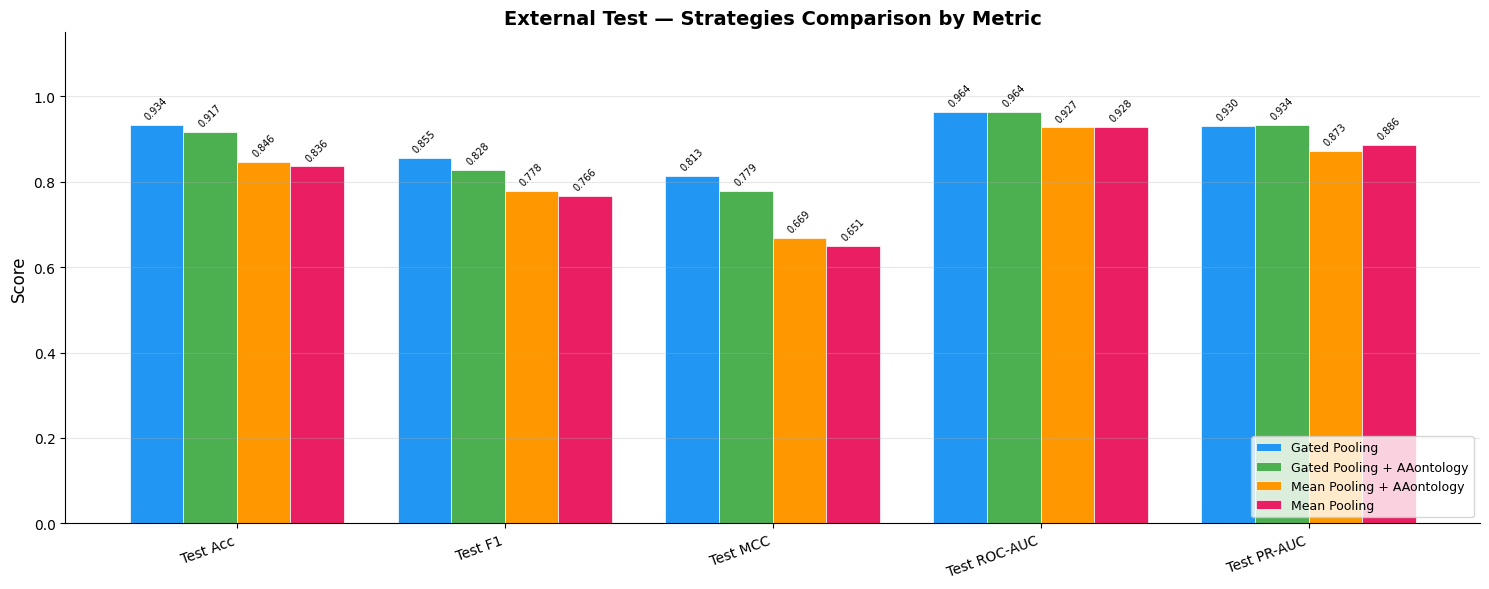

Saved: /kaggle/working/Validation/PoolingComparison/pooling_metrics_bar_chart_transposed.png


In [17]:
metric_cols = ["Test Acc", "Test F1", "Test MCC", "Test ROC-AUC", "Test PR-AUC"]
strategies = results_df["Strategy"].values
n_strategies = len(strategies)

fig, ax = plt.subplots(figsize=(15, 6))

x = np.arange(len(metric_cols))
width = 0.8 / n_strategies

# Colores para cada estrategia 
colors_bar = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63", "#9C27B0"][:n_strategies]

for j, (strategy, color) in enumerate(zip(strategies, colors_bar)):
    # Extraemos los valores de esta estrategia para todas las métricas
    row_vals = results_df.loc[results_df["Strategy"] == strategy, metric_cols].values[0].astype(float)
    
    bars = ax.bar(x + j * width, row_vals, width, label=strategy, color=color, edgecolor="white", linewidth=0.5)
    
    # Añadir etiquetas de valor sobre cada barra
    for bar, v in zip(bars, row_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7, rotation=45)

# Centrar las etiquetas del eje X 
ax.set_xticks(x + width * (n_strategies - 1) / 2)
ax.set_xticklabels(metric_cols, rotation=20, ha="right", fontsize=10)

ax.set_ylabel("Score", fontsize=12)
ax.set_title("External Test — Strategies Comparison by Metric", fontsize=14, fontweight="bold")

ax.legend(loc="lower right", fontsize=9)
ax.set_ylim(0, 1.15)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(EVAL_DIR / "pooling_metrics_bar_chart_transposed.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {EVAL_DIR / 'pooling_metrics_bar_chart_transposed.png'}")

## 📉 Superposición de Curvas ROC

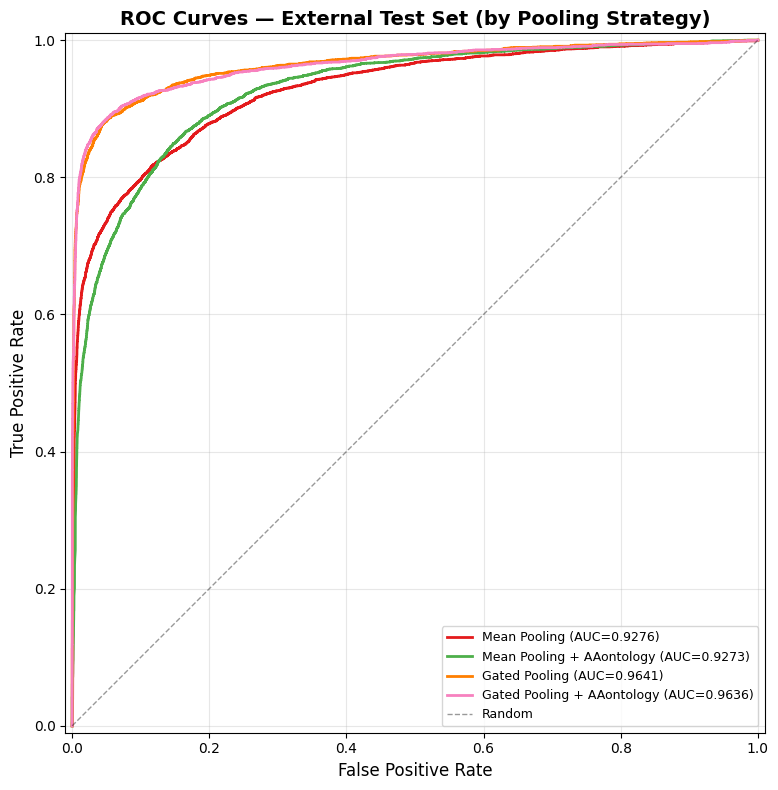

Saved: /kaggle/working/Validation/PoolingComparison/roc_curves_comparison.png


In [18]:
fig, ax = plt.subplots(figsize=(8, 8))
colors_line = plt.cm.Set1(np.linspace(0, 0.8, len(all_eval)))

for idx, r in enumerate(all_eval):
    auc_val = r["test_metrics"]["roc_auc"]
    ax.plot(r["fpr"], r["tpr"],
            label=f"{r['strategy']} (AUC={auc_val:.4f})",
            color=colors_line[idx], linewidth=2)

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, linewidth=1, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — External Test Set (by Pooling Strategy)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(EVAL_DIR / "roc_curves_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {EVAL_DIR / 'roc_curves_comparison.png'}")

## 🔢 Matrices de Confusión

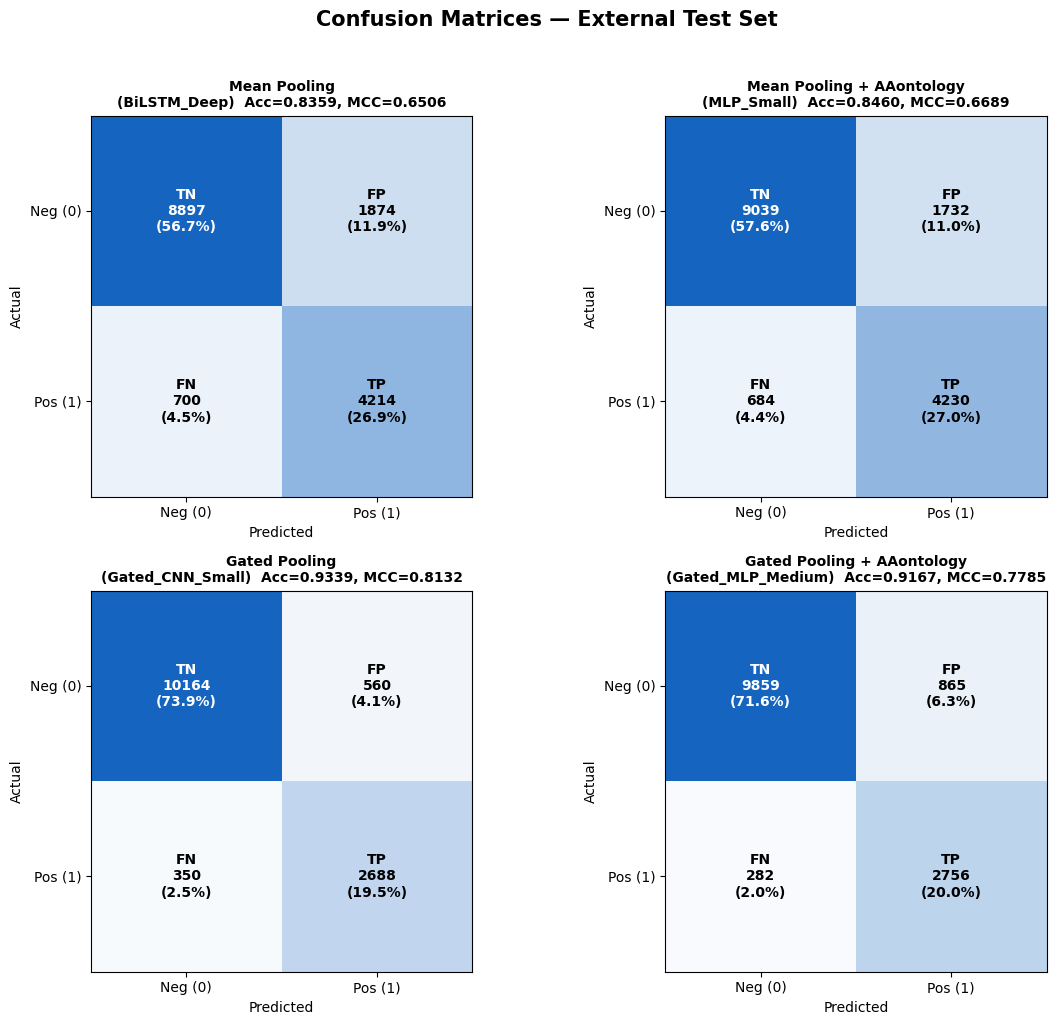

Saved: /kaggle/working/Validation/PoolingComparison/confusion_matrices.png


In [19]:
n_models = len(all_eval)
n_cols = min(2, n_models)
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), squeeze=False)
cmap_cm = LinearSegmentedColormap.from_list("custom_blue", ["#ffffff", "#1565C0"])

for idx, r in enumerate(all_eval):
    row_i, col_i = divmod(idx, n_cols)
    ax = axes[row_i][col_i]

    cm_data = r["test_metrics"]["confusion_matrix"]
    cm = np.array([[cm_data["tn"], cm_data["fp"]],
                    [cm_data["fn"], cm_data["tp"]]])

    total = cm.sum()
    im = ax.imshow(cm, interpolation="nearest", cmap=cmap_cm, vmin=0, vmax=cm.max())

    labels_text = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            pct = val / total * 100
            color = "white" if val > cm.max() * 0.6 else "black"
            ax.text(j, i, f"{labels_text[i][j]}\n{val}\n({pct:.1f}%)",
                    ha="center", va="center", fontsize=10, color=color, fontweight="bold")

    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Neg (0)", "Pos (1)"])
    ax.set_yticklabels(["Neg (0)", "Pos (1)"])
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("Actual", fontsize=10)
    acc = r["test_metrics"]["accuracy"]
    mcc = r["test_metrics"]["mcc"]
    ax.set_title(f"{r['strategy']}\n({r['name']})  Acc={acc:.4f}, MCC={mcc:.4f}", fontsize=10, fontweight="bold")

for idx in range(n_models, n_rows * n_cols):
    row_i, col_i = divmod(idx, n_cols)
    axes[row_i][col_i].set_visible(False)

fig.suptitle("Confusion Matrices — External Test Set", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(EVAL_DIR / "confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {EVAL_DIR / 'confusion_matrices.png'}")

## 🕸️ Gráfico de Radar

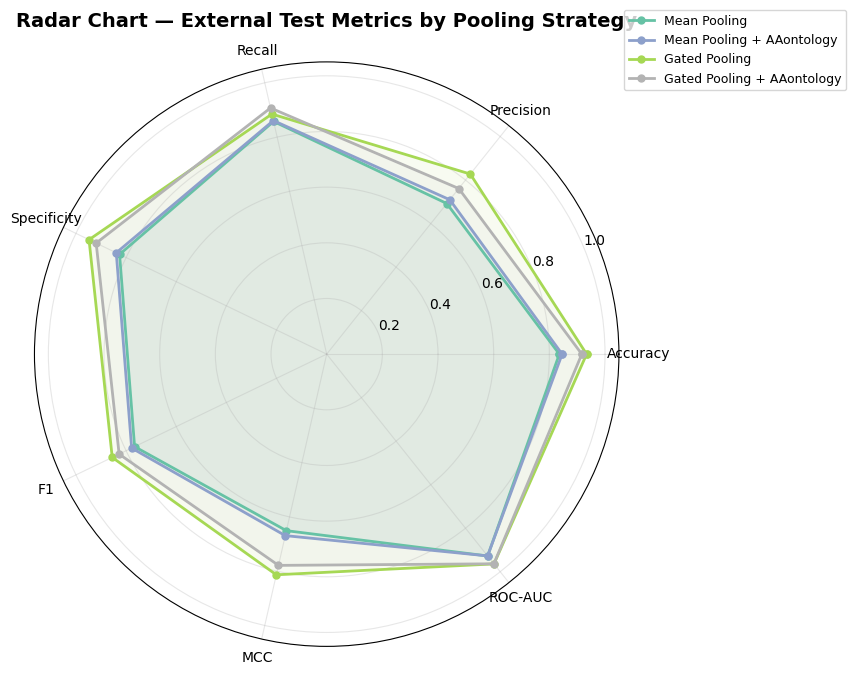

Saved: /kaggle/working/Validation/PoolingComparison/radar_chart.png


In [20]:
radar_metrics = ["accuracy", "precision", "recall", "specificity", "f1", "mcc", "roc_auc"]
radar_labels = ["Accuracy", "Precision", "Recall", "Specificity", "F1", "MCC", "ROC-AUC"]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

colors_radar = plt.cm.Set2(np.linspace(0, 0.9, len(all_eval)))

for idx, r in enumerate(all_eval):
    values = [r["test_metrics"].get(m, 0) or 0 for m in radar_metrics]
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=r["strategy"], color=colors_radar[idx], markersize=5)
    ax.fill(angles, values, alpha=0.08, color=colors_radar[idx])

ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Radar Chart — External Test Metrics by Pooling Strategy", fontsize=14, fontweight="bold", pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=9)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(EVAL_DIR / "radar_chart.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {EVAL_DIR / 'radar_chart.png'}")

## ⚖️ Validación vs Prueba

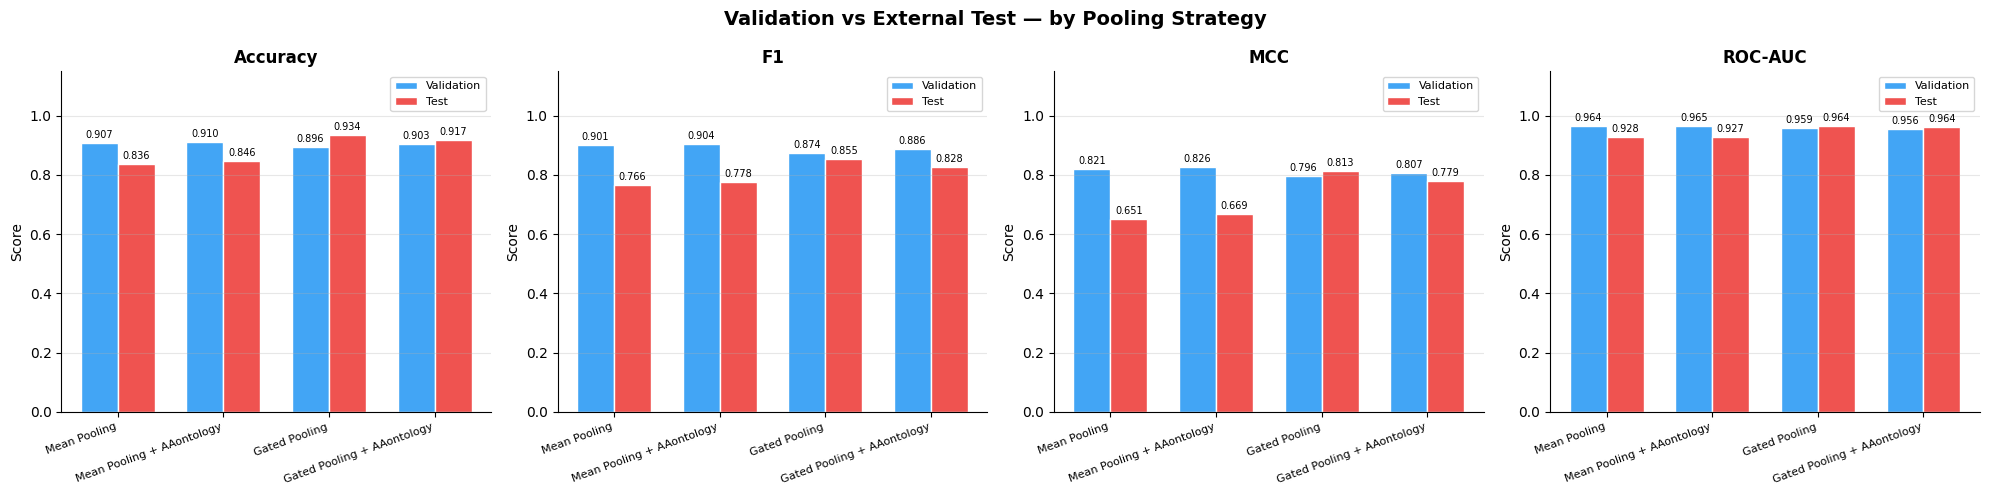

Saved: /kaggle/working/Validation/PoolingComparison/val_vs_test_comparison.png


In [21]:
val_test_metrics = ["accuracy", "f1", "mcc", "roc_auc"]
val_test_labels  = ["Accuracy", "F1", "MCC", "ROC-AUC"]

fig, axes = plt.subplots(1, len(val_test_metrics), figsize=(5 * len(val_test_metrics), 5))

strategy_names = [r["strategy"] for r in all_eval]
x = np.arange(len(strategy_names))
width_vt = 0.35

for ax_idx, (metric_key, metric_label) in enumerate(zip(val_test_metrics, val_test_labels)):
    ax = axes[ax_idx]

    val_vals, test_vals = [], []
    for r in all_eval:
        vm = r.get("val_metrics", {})
        tm = r["test_metrics"]
        val_vals.append(vm.get(metric_key, 0) or 0)
        test_vals.append(tm.get(metric_key, 0) or 0)

    bars1 = ax.bar(x - width_vt / 2, val_vals, width_vt, label="Validation", color="#42A5F5", edgecolor="white")
    bars2 = ax.bar(x + width_vt / 2, test_vals, width_vt, label="Test", color="#EF5350", edgecolor="white")

    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.3f}", ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(strategy_names, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("Score")
    ax.set_title(metric_label, fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Validation vs External Test — by Pooling Strategy", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(EVAL_DIR / "val_vs_test_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {EVAL_DIR / 'val_vs_test_comparison.png'}")

## 💾 Guardar Todas las Métricas como JSON

In [22]:
all_metrics_json = {}
for r in all_eval:
    all_metrics_json[r["strategy"]] = {
        "model_name": r["name"],
        "config": r["config"],
        "n_params": r["n_params"],
        "best_train_epoch": r["best_train_epoch"],
        "best_val_loss": r["best_val_loss"],
        "val_metrics": r.get("val_metrics", {}),
        "test_metrics": {k: v for k, v in r["test_metrics"].items() if k != "confusion_matrix"},
        "test_confusion_matrix": r["test_metrics"]["confusion_matrix"],
    }

json_path = EVAL_DIR / "pooling_comparison_metrics.json"
with open(json_path, "w") as f:
    json.dump(all_metrics_json, f, indent=2)
print(f"\nSaved: {json_path}")


Saved: /kaggle/working/Validation/PoolingComparison/pooling_comparison_metrics.json


## 🏁 Resumen Final

In [23]:
print("\n" + "=" * 90)
print("EVALUATION SUMMARY — POOLING STRATEGY COMPARISON")
print("=" * 90)
print(f"External test set: ({len(y_test_flat)} samples)")
print(f"Strategies evaluated: {len(all_eval)}")
print(f"Threshold: {THRESHOLD}")
print()

print("Final Ranking (by Test MCC):")
for idx, row in results_df.iterrows():
    print(f"  #{idx} {row['Strategy']:28s} ({row['Model']:20s}) | "
          f"Acc={row['Test Acc']:.4f} F1={row['Test F1']:.4f} "
          f"MCC={row['Test MCC']:.4f} AUC={row['Test ROC-AUC']:.4f} "
          f"PR-AUC={row['Test PR-AUC']:.4f}")

print(f"\n🏆 Best strategy on external test: {best_strategy} ({best_entry['name']})")
bm = best_entry["test_metrics"]
print(f"   Acc={bm['accuracy']:.4f} | F1={bm['f1']:.4f} | MCC={bm['mcc']:.4f} | "
      f"AUC={bm['roc_auc']:.4f} | PR-AUC={bm['pr_auc']:.4f}")

print(f"\nOutput directory: {EVAL_DIR.resolve()}")
print("Files generated:")
for f in sorted(EVAL_DIR.glob("*")):
    size = f.stat().st_size
    print(f"  {f.name:45s} ({size / 1024:.1f} KB)")
print("=" * 90)


EVALUATION SUMMARY — POOLING STRATEGY COMPARISON
External test set: (15685 samples)
Strategies evaluated: 4
Threshold: 0.5

Final Ranking (by Test MCC):
  #1 Gated Pooling                (Gated_CNN_Small     ) | Acc=0.9339 F1=0.8552 MCC=0.8132 AUC=0.9641 PR-AUC=0.9304
  #2 Gated Pooling + AAontology   (Gated_MLP_Medium    ) | Acc=0.9167 F1=0.8278 MCC=0.7785 AUC=0.9636 PR-AUC=0.9336
  #3 Mean Pooling + AAontology    (MLP_Small           ) | Acc=0.8460 F1=0.7779 MCC=0.6689 AUC=0.9273 PR-AUC=0.8732
  #4 Mean Pooling                 (BiLSTM_Deep         ) | Acc=0.8359 F1=0.7660 MCC=0.6506 AUC=0.9276 PR-AUC=0.8864

🏆 Best strategy on external test: Gated Pooling (Gated_CNN_Small)
   Acc=0.9339 | F1=0.8552 | MCC=0.8132 | AUC=0.9641 | PR-AUC=0.9304

Output directory: /kaggle/working/Validation/PoolingComparison
Files generated:
  confusion_matrices.png                        (205.0 KB)
  pooling_comparison_metrics.json               (5.0 KB)
  pooling_comparison_table.csv                  (1

## 🏆 Conclusión sobre la Mejor Estrategia de Pooling


**Ranking en el test externo (15,685 muestras), por MCC:**

| # | Estrategia | Modelo | Acc | F1 | MCC | AUC | PR-AUC |
|---|---|---|---|---|---|---|---|
| 1 | Gated Pooling | Gated_CNN_Small | 0.9339 | 0.8552 | **0.8132** | 0.9641 | 0.9304 |
| 2 | Gated Pooling + AAontology | Gated_MLP_Medium | 0.9167 | 0.8278 | 0.7785 | 0.9636 | **0.9336** |
| 3 | Mean Pooling + AAontology | MLP_Small | 0.8460 | 0.7779 | 0.6689 | 0.9273 | 0.8732 |
| 4 | Mean Pooling | BiLSTM_Deep | 0.8359 | 0.7660 | 0.6506 | 0.9276 | 0.8864 |

### 📌 Hallazgos Clave

1. **La estrategia de pooling pesa más que AAontology.** El salto de Mean → Gated es mucho mayor que cualquier efecto de AAontology: +0.16 MCC sin AAontology (0.8132 vs 0.6506) y +0.11 MCC con AAontology (0.7785 vs 0.6689). Un pooling aprendido, que decide *qué* residuos importan a partir del propio embedding, captura mucha más señal discriminativa que un promedio uniforme.

2. **AAontology ayuda con Mean Pooling, pero no con Gated Pooling — y el signo se invierte.** Bajo Mean Pooling, agregar AAontology mejora el MCC (+0.018) y el Acc (+0.010). Bajo Gated Pooling, agregarla lo empeora (−0.035 MCC, −0.017 Acc). La única métrica que sube con AAontology en el régimen Gated es el PR-AUC (0.9336 vs 0.9304), sugiriendo que sobre la clase positiva específicamente el perfil por residuo todavía aporta algo, aunque no se traduzca en mejor discriminación global con el umbral de 0.5.

3. **Interpretación:** esto es consistente con el patrón que motivó esta comparación. Con Mean Pooling el modelo no tiene forma de aprender qué residuos pesan más, así que un prior bioquímico explícito (AAontology) sí añade información que el modelo no podía inferir solo. Con Gated Pooling el modelo ya aprende, directamente del embedding de ProtFlash, unos pesos de atención por residuo — inyectar AAontology encima parece ser en parte redundante con lo que el gate ya aprende, o añade complejidad (más parámetros, optimización más difícil) que no se paga en este test set.